Task 4 - Decision Tree

1. Build a decision tree classifier using the Iris dataset.

2. Visualize the decision tree and interpret the first two splits.

3. Use a decision tree regressor on a housing dataset to predict house prices. Tune the tree’s depth and analyze how it affects overfitting.



In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Lasso,Ridge,LassoCV,RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
import math

In [ ]:
data = load_iris()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
x_train, x_test,y_train, y_test = train_test_split(x, y,test_size=0.33,random_state=42)
treemodel = DecisionTreeClassifier()
treemodel.fit(x_train, y_train)

DecisionTreeClassifier()

0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.94      0.97        16
           2       0.94      1.00      0.97        15

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



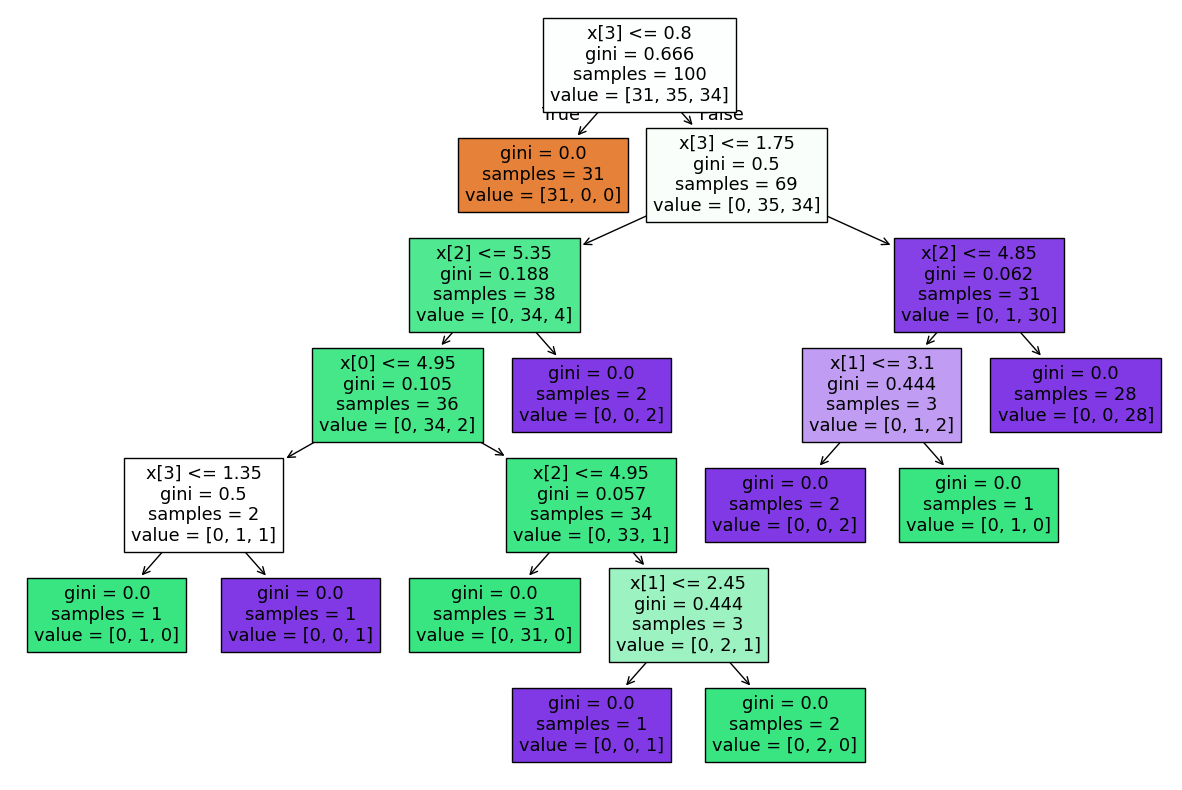

In [ ]:
from sklearn import tree
from sklearn.metrics import accuracy_score,classification_report
plt.figure(figsize=(15, 10))
tree.plot_tree(treemodel, filled=True)
y_pred = treemodel.predict(x_test)
score = accuracy_score(y_pred, y_test)
print(score)
print(classification_report(y_pred, y_test))

In [17]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1)
data = pd.DataFrame(boston.data,columns=boston.feature_names)
data.head(10)
x_train, x_test,y_train, y_test = train_test_split(x, y,test_size=0.33,random_state=42)

[0.17246376811594202, 0.04546689303904923, 0.025555555555555554, 0.014705882352941175, 0.006666666666666666, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


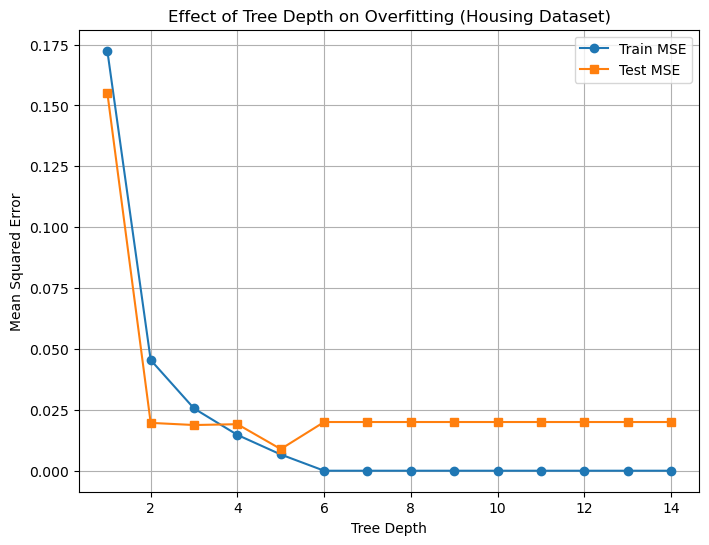

In [ ]:


depths = range(1, 15)
train_errors, test_errors = [], []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(x_train, y_train)
    
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# Plot the results

plt.figure(figsize=(8, 6))
plt.plot(depths, train_errors, marker='o', label='Train MSE')
plt.plot(depths, test_errors, marker='s', label='Test MSE')
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Tree Depth on Overfitting (Housing Dataset)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
train_errors
## we can see  after 5 depth model overfit on the data


[0.17246376811594202,
 0.04546689303904923,
 0.025555555555555554,
 0.014705882352941175,
 0.006666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]